In [4]:
import numpy as np
import EFC_learningfMRI.globals as gl
from EFC_learningfMRI.util import get_trained_and_untrained, add_flexion_imbalance
from EFC_learningfMRI.vis import plot_im_sess
from EFC_learningfMRI.G_matrix import G_sorted#, lme_trained_untrained
from EFC_learningfMRI.pcm import subj_spec_models
import os
import pandas as pd
import PcmPy as pcm
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import seaborn as sb

warnings.filterwarnings('ignore')

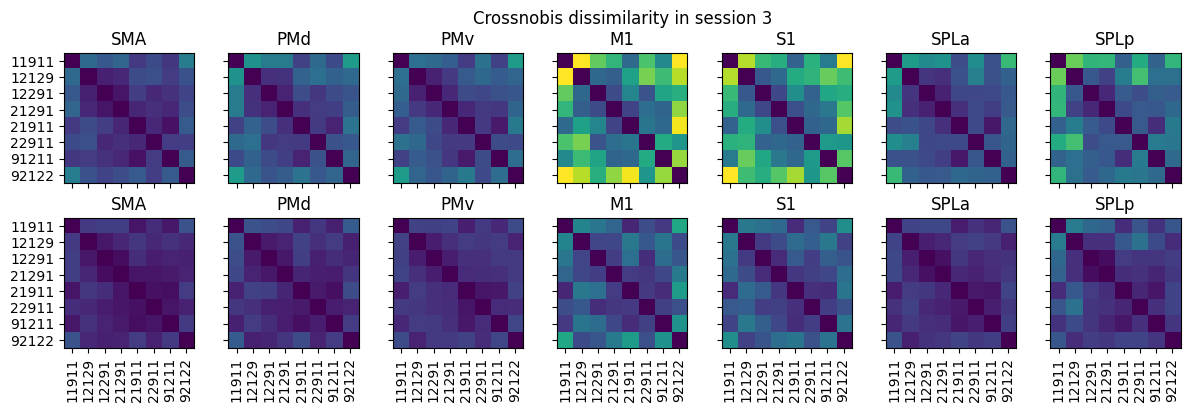

In [32]:
H    = 'L'
rois = gl.rois['ROI']
glm  = 2
sns  = gl.participants

fig, axs = plt.subplots(2, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(12, 4))

vmin, vmax = 0, .5

for r, roi in enumerate(rois):
    for rep in range(2):
        G  = []
        for sn in sns:
            G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs.within_session.3.{rep+1}.glm{glm}.{H}.{roi}.npy')))
        G  = np.array(G)
    
        ax = axs[rep, r]
        G_sort  = G_sorted(G, sns, order=gl.chordID)
        D  = pcm.G_to_dist(G_sort)
        ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
        ax.set_xticks(np.arange(8))
        ax.set_yticks(np.arange(8))
        ax.set_xticklabels(gl.chordID, rotation=90)
        ax.set_yticklabels(gl.chordID)
        ax.set_title(f'Crossnobis dissimilarity in session 3\n{roi}' if r==3 and rep==0 else roi)

plt.show()

In [1]:
H    = 'L'
rois = gl.rois['ROI']
glm  = 2
sns  = gl.participants

fig, axs = plt.subplots(2, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(12, 4))

vmin, vmax = 0, .5

for r, roi in enumerate(rois):
    G  = []
    for sn in sns:
        G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs.within_session.3.glm{glm}.{H}.{roi}.npy')))
    G  = np.array(G)

    ax = axs[rep, r]
    G_sort  = G_sorted(G, sns, order=gl.chordID)
    D  = pcm.G_to_dist(G_sort)
    ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(8))
    ax.set_yticks(np.arange(8))
    ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(f'Crossnobis dissimilarity in session 3\n{roi}' if r==3 and rep==0 else roi)

plt.show()

NameError: name 'gl' is not defined

In [13]:
import pingouin as pg

# chord (trained/untrained) x session repeated-measures ANOVA, per ROI
rm  = dist_chord_sess[dist_chord_sess.chord.isin(['trained', 'untrained'])]
aov = pd.concat(
    [pg.rm_anova(d, dv='crossnobis', within=['chord', 'session'], subject='sn').assign(roi=roi)
     for roi, d in rm.groupby('roi')],
    ignore_index=True)

# GG-corrected p per effect, one row per ROI (chord*session = does the gap change with training?)
pvals = aov.pivot(index='roi', columns='Source', values='p_GG_corr')[['chord', 'session', 'chord * session']]
print(pvals.round(4))
aov

Source   chord  session  chord * session
roi                                     
M1      0.4332   0.5856           0.2500
PMd     0.7082   0.9822           0.5404
PMv     0.2151   0.7797           0.6954
S1      0.3403   0.5053           0.0589
SMA     0.5334   0.7376           0.9679
SPLa    0.4692   0.4067           0.4709
SPLp    0.4232   0.3258           0.2772


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps,roi
0,chord,0.003344,1,12,0.003344,0.657546,0.433216,0.433216,0.003328,1.000000,M1
1,session,0.007589,2,24,0.003795,0.416031,0.664326,0.585550,0.007520,0.665731,M1
2,chord * session,0.004590,2,24,0.002295,1.481811,0.247284,0.250040,0.004562,0.766476,M1
3,chord,0.000167,1,12,0.000167,0.146886,0.708233,0.708233,0.000667,1.000000,PMd
4,session,0.000051,2,24,0.000026,0.012083,0.987996,0.982203,0.000204,0.897093,PMd
5,chord * session,0.000375,2,24,0.000187,0.574908,0.570318,0.540390,0.001494,0.826721,PMd
6,chord,0.002545,1,12,0.002545,1.712904,0.215119,0.215119,0.009455,1.000000,PMv
7,session,0.000795,2,24,0.000398,0.193169,0.825612,0.779699,0.002973,0.807135,PMv
8,chord * session,0.000353,2,24,0.000176,0.240586,0.788040,0.695395,0.001322,0.657350,PMv
9,chord,0.002976,1,12,0.002976,0.986308,0.340251,0.340251,0.003632,1.000000,S1


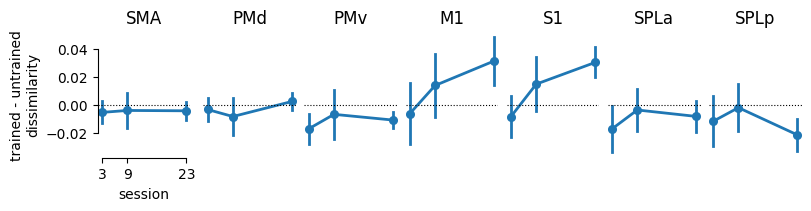

In [12]:
# per-subject trained - untrained difference in crossnobis, then mean +/- se per roi/session
wide = dist_chord_sess.pivot_table(index=['sn', 'Hem', 'roi', 'session'],
                                   columns='chord', values='crossnobis')
diff = (wide['trained'] - wide['untrained']).rename('diff').reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)
plot_im_sess(fig, axs, diff, rois, y='diff', x='session', kind='point', add_zero=True, dodge=False, estimator='mean')
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('trained - untrained\ndissimilarity')
axs[0].set_xlabel('session')
plt.show()

     roi  session    ci_low   ci_high         p
1    SMA        3 -0.019075  0.007326  0.383083
10   PMd        3 -0.017030  0.008728  0.527554
19   PMv        3 -0.032693 -0.002122  0.025614
28    M1        3 -0.037734  0.025065  0.692553
37    S1        3 -0.034961  0.018104  0.533533
46  SPLa        3 -0.035561 -0.000522  0.043557
55  SPLp        3 -0.033303  0.005738  0.166410
22   PMv        9 -0.027727  0.013789  0.510548
40    S1        9 -0.006944  0.036502  0.182385
31    M1        9 -0.014879  0.042337  0.346908
13   PMd        9 -0.024550  0.006161  0.240560
4    SMA        9 -0.019257  0.010122  0.542238
49  SPLa        9 -0.020638  0.012001  0.604034
58  SPLp        9 -0.022400  0.015613  0.726393
16   PMd       23 -0.013204  0.016197  0.841854
7    SMA       23 -0.022607  0.012241  0.559869
43    S1       23  0.008078  0.052385  0.007480
34    M1       23  0.001305  0.060987  0.040791
25   PMv       23 -0.028721  0.005724  0.190686
52  SPLa       23 -0.028608  0.009164  0

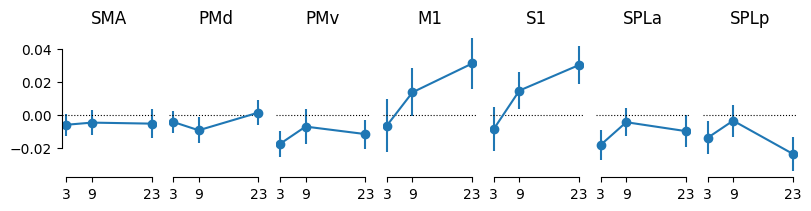

In [5]:
result = lme_trained_untrained(dist)
chord  = result[result.term == 'chord'].sort_values('session')

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

for r, roi in enumerate(rois):
    ax        = axs[r]
    chord_roi = chord[chord.roi==roi]
    ax.errorbar(chord_roi.session, chord_roi.beta, yerr=chord_roi.se, marker='o')
    ax.axhline(0, color='k', lw=.8, ls=':')
    ax.set_title(roi)
    ax.set_xticks(sorted(chord_roi.session.unique()))
    ax.tick_params(left=r==0)

for i, ax in enumerate(axs):sb.despine(ax=ax, trim=True, left=i>0)

print(chord[['roi', 'session', 'ci_low', 'ci_high', 'p']])

plt.show()

In [6]:
rng     = np.random.default_rng(0)
n_perm  = 1000                       # lower for a quick look; ~0.3 s per permutation

def shuffle_trained_untrained(df, rng):
    """Give each subject a random 4-of-8 'trained' set and reclassify every pair."""
    df[['a', 'b']] = df.pair.str.split('-', expand=True)
    out            = df.copy()
    for sn, g in df.groupby('sn'):
        tr   = set(rng.choice(np.array(gl.chordID, dtype=str), 4, replace=False))   # this subject's trained chords
        a, b = g.a.isin(tr), g.b.isin(tr)
        out.loc[g.index, 'chord'] = np.where(a & b, 'trained', np.where(~a & ~b, 'untrained', 'trained_untrained'))
    return out

# permutation loop: shuffle labels -> refit -> append
rows = []
for i in range(n_perm):
    dist_perm    = shuffle_trained_untrained(dist, rng)
    res_perm_tmp = lme_trained_untrained(dist_perm)
    rows.append(res_perm_tmp)

result_perm = pd.concat(rows, axis=0)

term, keys = 'chord', ['Hem', 'roi', 'session']

obs  = result.loc[result.term == term, keys + ['beta']].rename(columns={'beta': 'beta_obs'})
perm = result_perm.loc[result_perm.term == term, keys + ['beta']]

p_perm = (perm.merge(obs, on=keys)
              .assign(extreme=lambda d: d.beta.abs() >= d.beta_obs.abs())   # two-sided: |perm| >= |obs|
              .groupby(keys)
              .agg(n=('extreme', 'size'), n_extreme=('extreme', 'sum'))
              .assign(p_perm=lambda d: (1 + d.n_extreme) / (1 + d.n))       # +1 correction
              .reset_index())

              


   Hem   roi  session    n  n_extreme    p_perm
0    L    M1        3  100         80  0.801980
1    L    M1        9  100         60  0.603960
2    L    M1       23  100         13  0.138614
3    L   PMd        3  100         70  0.702970
4    L   PMd        9  100         43  0.435644
5    L   PMd       23  100         89  0.891089
6    L   PMv        3  100         17  0.178218
7    L   PMv        9  100         61  0.613861
8    L   PMv       23  100         39  0.396040
9    L    S1        3  100         68  0.683168
10   L    S1        9  100         35  0.356436
11   L    S1       23  100          5  0.059406
12   L   SMA        3  100         45  0.455446
13   L   SMA        9  100         69  0.693069
14   L   SMA       23  100         71  0.712871
15   L  SPLa        3  100         25  0.257426
16   L  SPLa        9  100         65  0.653465
17   L  SPLa       23  100         62  0.623762
18   L  SPLp        3  100         34  0.346535
19   L  SPLp        9  100         83  0

In [9]:
print(p_perm.sort_values('session'))


   Hem   roi  session    n  n_extreme    p_perm
0    L    M1        3  100         80  0.801980
3    L   PMd        3  100         70  0.702970
6    L   PMv        3  100         17  0.178218
9    L    S1        3  100         68  0.683168
12   L   SMA        3  100         45  0.455446
15   L  SPLa        3  100         25  0.257426
18   L  SPLp        3  100         34  0.346535
7    L   PMv        9  100         61  0.613861
13   L   SMA        9  100         69  0.693069
10   L    S1        9  100         35  0.356436
4    L   PMd        9  100         43  0.435644
1    L    M1        9  100         60  0.603960
16   L  SPLa        9  100         65  0.653465
19   L  SPLp        9  100         83  0.831683
5    L   PMd       23  100         89  0.891089
2    L    M1       23  100         13  0.138614
14   L   SMA       23  100         71  0.712871
11   L    S1       23  100          5  0.059406
8    L   PMv       23  100         39  0.396040
17   L  SPLa       23  100         62  0

In [7]:
result_perm
chord_perm  = result_perm[result_perm.term == 'chord'].sort_values('session')
chord_perm[chord_perm.roi=='SMA']

,Hem,roi,session,term,beta,se,z,p,ci_low,ci_high,subject_var,converged,n_obs,n_subj
1,L,SMA,3,chord,-0.002272,0.006607,-0.343940,0.730891,-0.015222,0.010677,0.001006,True,156,13
1,L,SMA,3,chord,-0.005265,0.006275,-0.839019,0.401459,-0.017564,0.007034,0.001134,True,156,13
1,L,SMA,3,chord,-0.007384,0.005606,-1.317027,0.187830,-0.018371,0.003604,0.001204,True,156,13
1,L,SMA,3,chord,-0.009053,0.006384,-1.418053,0.156175,-0.021565,0.003460,0.001331,True,156,13
1,L,SMA,3,chord,-0.001030,0.005284,-0.194922,0.845454,-0.011387,0.009327,0.001042,True,156,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,L,SMA,23,chord,0.003973,0.011336,0.350478,0.725980,-0.018245,0.026192,0.005154,True,156,13
7,L,SMA,23,chord,-0.014075,0.012569,-1.119767,0.262813,-0.038710,0.010561,0.006864,True,156,13
7,L,SMA,23,chord,0.002333,0.011560,0.201813,0.840063,-0.020324,0.024990,0.007070,True,156,13
7,L,SMA,23,chord,0.007014,0.010362,0.676926,0.498453,-0.013294,0.027323,0.006100,True,156,13


In [8]:
perm_b = pd.DataFrame(perm_b)

# per-region permutation p (two-sided): is the observed beta2 out in the tail?
perm_pval = (perm_b.abs() >= obs_b.abs()).mean(axis=0)
summary = pd.DataFrame({'beta2': obs_b, 'p_parametric': obs_p, 'p_perm': perm_pval}).reindex(rois)
print(summary.round(4))

# multiple-regions test: are MORE regions parametric-significant than the null gives by chance?
obs_count  = (obs_p < .05).sum()
null_count = (perm_p < .05).sum(axis=1)      # per permutation, how many regions cross p<.05
print(f"\nregions with parametric p<.05: observed={obs_count}, "
      f"null mean={null_count.mean():.2f}, p={(null_count >= obs_count).mean():.3f}")

# observed beta2 (red) against its permutation null per region
fig, axs = plt.subplots(1, len(rois), figsize=(14, 2.2), constrained_layout=True)
for ax, roi in zip(axs, rois):
    ax.hist(perm_b[roi], bins=40, color='0.8')
    ax.axvline(obs_b[roi], color='red', lw=1.5)
    ax.axvline(0, color='k', lw=.5)
    ax.set_title(f"{roi}\n$p_{{perm}}$={perm_pval[roi]:.2f}", fontsize=9)
    ax.set_yticks([])
axs[0].set_ylabel('permutations')
sb.despine(fig, left=True)
plt.show()

NameError: name 'perm_b' is not defined